In [ ]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib

Using matplotlib backend: module://matplotlib_inline.backend_inline


: 

In [2]:
df = pd.read_csv('../data/BVBRC_genome_amr.csv', index_col=0)
df

C:\Users\Mr_Nnobody\AppData\Local\Temp\ipykernel_26572\1929598575.py:1: DtypeWarning: Columns (19) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../data/BVBRC_genome_amr.csv', index_col=0)


,Genome ID,Genome Name,Antibiotic,Resistant Phenotype,Measurement,Measurement Sign,Measurement Value,Measurement Unit,Laboratory Typing Method,Laboratory Typing Method Version,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
Taxon ID,,,,,,,,,,,,,,,,,,,,
562,562.144628,Escherichia coli 10,ceftriaxone,NaN,<=0.25,<=,0.25,mg/L,MIC,NaN,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686
562,562.569100,Escherichia coli CVM N36113PS,trimethoprim/sulfamethoxazole,NaN,<=0.12,<=,0.12,mg/L,Broth dilution,NaN,Sensititre,Thermo Fisher Scientific,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,26142410,26142410
562,562.144245,Escherichia coli ERR7221502,meropenem,Susceptible,NaN,NaN,NaN,NaN,Broth dilution,NaN,VITEK 2,BioMerieux,EUCAST,2016.0,NaN,NaN,NaN,Laboratory Method,NaN,36916881
562,562.100003,Escherichia coli c1b4da3e-7bb9-11e9-a8d3-68b59...,trimethoprim/sulfamethoxazole,Susceptible,NaN,NaN,NaN,NaN,Disk diffusion,NaN,NaN,NaN,EUCAST,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
562,562.143892,Escherichia coli JBDIABB-19-0096,piperacillin/tazobactam,NaN,<=4,<=,4,mg/L,MIC,NaN,NaN,Beckman Coulter Inc,CLSI,2021.0,NaN,NaN,NaN,Laboratory Method,NaN,38052776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,562.144668,Escherichia coli 38,amoxicillin/clavulanic acid,NaN,8,NaN,8,mg/L,MIC,NaN,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686
562,562.236000,Escherichia coli O17:H18 strain ECO1306,gentamicin,NaN,0.5,NaN,0.5,mg/L,MIC,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,38219757
562,562.990490,Escherichia coli c4faf2ce-7bb8-11e9-a8d3-68b59...,tigecycline,Susceptible,NaN,NaN,NaN,NaN,Disk diffusion,NaN,NaN,NaN,EUCAST,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 242917 entries, 562 to 562
Data columns (total 20 columns):
 #   Column                            Non-Null Count   Dtype  
---  ------                            --------------   -----  
 0   Genome ID                         242917 non-null  float64
 1   Genome Name                       242917 non-null  object 
 2   Antibiotic                        242917 non-null  object 
 3   Resistant Phenotype               93629 non-null   object 
 4   Measurement                       171962 non-null  object 
 5   Measurement Sign                  89387 non-null   object 
 6   Measurement Value                 171974 non-null  object 
 7   Measurement Unit                  171963 non-null  object 
 8   Laboratory Typing Method          242917 non-null  object 
 9   Laboratory Typing Method Version  162 non-null     object 
 10  Laboratory Typing Platform        41663 non-null   object 
 11  Vendor                            118539 non-null  object 

In [4]:
# Check the distribution of the target variable
df['Resistant Phenotype'].value_counts()

Resistant Phenotype
Susceptible                   70815
Resistant                     20789
Intermediate                   2015
Nonsusceptible                    6
Susceptible-dose dependent        4
Name: count, dtype: int64

In [5]:
# Check antibiotic distribution and count unique antibiotics
df['Antibiotic'].value_counts()

Antibiotic
ciprofloxacin              15895
ceftazidime                15238
piperacillin/tazobactam    14052
cefotaxime                 13890
gentamicin                 13464
                           ...  
teicoplanin                    1
linezolid                      1
vancomycin                     1
cephalexin                     1
metronidazole                  1
Name: count, Length: 96, dtype: int64

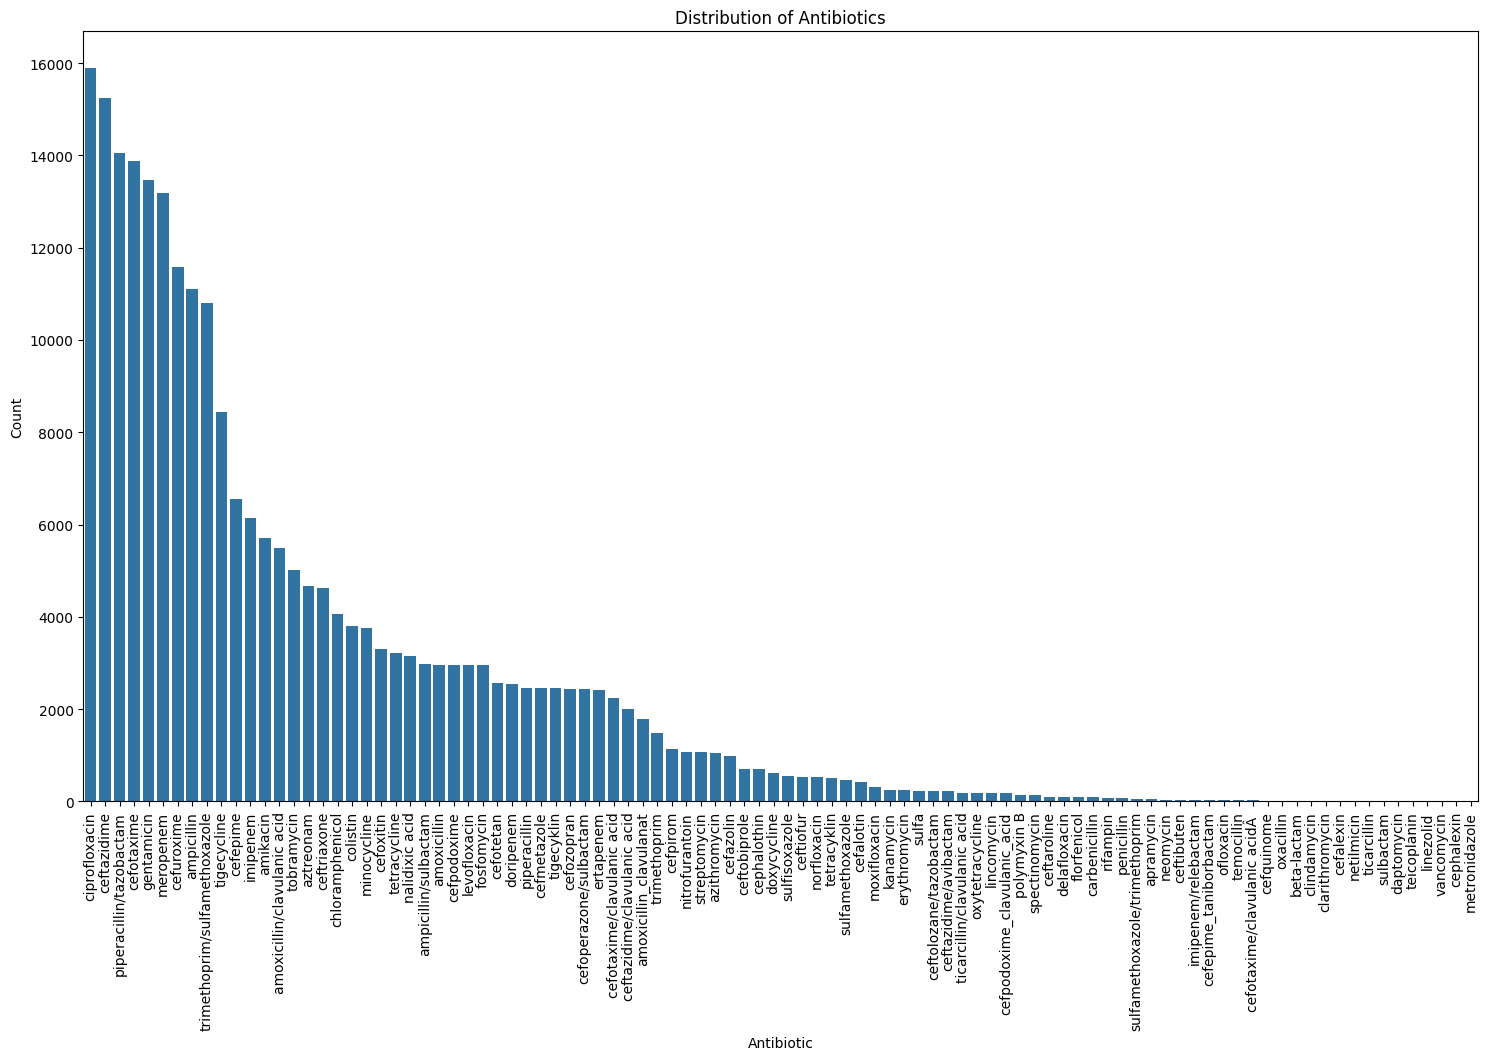

In [21]:
# plot antibiotic distribution
plt.figure(figsize=(18,10))
sns.countplot(data=df, x='Antibiotic', order=df['Antibiotic'].value_counts().index)
plt.xticks(rotation=90)
plt.xlabel('Antibiotic')
plt.ylabel('Count')
plt.title('Distribution of Antibiotics')
plt.show()

In [6]:
len(df.Antibiotic.unique())

96

In [7]:
len(df['Genome Name'].unique())

12743

## Merge Data

Merge Phonotypic and Genome data together on Genome ID and Genome Name such that it keeps corresponding entries from each dataset

In [8]:
# getting genome data
genome_data = pd.read_csv('../data/BVBRC_genome (1).csv', index_col=0)


# right join to combine both dataframes on the genome id
combined_df = pd.merge(genome_data, df, on=['Genome ID','Genome Name'], how='right')
combined_df

C:\Users\Mr_Nnobody\AppData\Local\Temp\ipykernel_26572\582542800.py:2: DtypeWarning: Columns (17,33,34,37,83,84) have mixed types. Specify dtype option on import or set low_memory=False.
  genome_data = pd.read_csv('../data/BVBRC_genome (1).csv', index_col=0)


,Genome ID,Genome Name,Other Names,NCBI Taxon ID,Taxon Lineage IDs,Taxon Lineage Names,Superkingdom,Kingdom,Phylum,Class,...,Laboratory Typing Platform,Vendor,Testing Standard,Testing Standard Year,Computational Method,Computational Method Version,Computational Method Performance,Evidence,Source,PubMed
0,562.144628,Escherichia coli 10,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686
1,562.569100,Escherichia coli CVM N36113PS,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,Sensititre,Thermo Fisher Scientific,CLSI,NaN,NaN,NaN,NaN,Laboratory Method,26142410,26142410
2,562.144245,Escherichia coli ERR7221502,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,VITEK 2,BioMerieux,EUCAST,2016.0,NaN,NaN,NaN,Laboratory Method,NaN,36916881
3,562.100003,Escherichia coli c1b4da3e-7bb9-11e9-a8d3-68b59...,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,EUCAST,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
4,562.143892,Escherichia coli JBDIABB-19-0096,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,Beckman Coulter Inc,CLSI,2021.0,NaN,NaN,NaN,Laboratory Method,NaN,38052776
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
242912,562.144668,Escherichia coli 38,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,CLSI,2018.0,NaN,NaN,NaN,Laboratory Method,NaN,36165686
242913,562.236000,Escherichia coli O17:H18 strain ECO1306,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,38219757
242914,562.990490,Escherichia coli c4faf2ce-7bb8-11e9-a8d3-68b59...,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,EUCAST,NaN,NaN,NaN,NaN,Laboratory Method,NaN,NaN
242915,562.978750,Escherichia coli 1119ae66-7bb9-11e9-a8d3-68b59...,NaN,562.0,131567;2;3379134;1224;1236;91347;543;561;562,cellular organisms;Bacteria;Pseudomonadati;Pse...,Bacteria,Pseudomonadati,Pseudomonadota,Gammaproteobacteria,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Laboratory Method,NaN,38219757


In [9]:
len(combined_df['Genome Name'].unique())

12743

## AMR Matrix Transformation
We will now transform the data so that:
1. Each **Genome** is a row.
2. Each **Antibiotic** is a column.
3. The values are encoded: **Susceptible (0), Intermediate (1), Resistant (2), Nonsusceptible(2)**.


In [10]:
# Map Phenotypes to Numbers
phenotype_map = {
    'Susceptible': 0,
    'Intermediate': 1,
    'Resistant': 2,
    'Nonsusceptible': 2, # Treat NonSusceptible as Resistant for simplicity
}

# Filter out rows where 'Resistant Phenotype' is missing or not in our map
clean_df = combined_df[combined_df['Resistant Phenotype'].isin(phenotype_map.keys())].copy()
clean_df['Phenotype_Code'] = clean_df['Resistant Phenotype'].map(phenotype_map)
print("Unique antibiotics after filtering:", len(clean_df.Antibiotic.unique()))
print("Unique genomes after filtering:", len(clean_df['Genome Name'].unique()))

# Pivot the table indexing with Genome Name
amr_matrix = clean_df.pivot_table(
    index= ['Genome Name'], 
    columns='Antibiotic', 
    values='Phenotype_Code',
    aggfunc='max' # If there are duplicates, take the higher resistance (worst-case scenario)
)

amr_matrix


Unique antibiotics after filtering: 78
Unique genomes after filtering: 7884


Antibiotic,amikacin,amoxicillin,amoxicillin/clavulanic acid,ampicillin,ampicillin/sulbactam,apramycin,azithromycin,aztreonam,beta-lactam,carbenicillin,...,teicoplanin,temocillin,tetracycline,ticarcillin,ticarcillin/clavulanic acid,tigecycline,tobramycin,trimethoprim,trimethoprim/sulfamethoxazole,vancomycin
Genome Name,,,,,,,,,,,,,,,,,,,,,
Escherichia coli 001-E1-DxU,0.0,NaN,NaN,2.0,2.0,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
Escherichia coli 001-E1-S04,0.0,NaN,NaN,2.0,2.0,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
Escherichia coli 001-E1-S06,0.0,NaN,NaN,2.0,2.0,NaN,NaN,2.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.0,NaN
Escherichia coli 00116690-7bb9-11e9-a8d3-68b59976a384,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,2.0,NaN
Escherichia coli 002-E1-DxU,0.0,NaN,NaN,2.0,2.0,NaN,NaN,0.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Escherichia coli strain WU40,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
Escherichia coli strain WU43,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
Escherichia coli strain WU44,NaN,NaN,NaN,2.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN



## Cleaning Antibiotics

Removing antibiotics which have more missing values or just a few actual Phenotypic label



In [11]:
# checking for missing values
missing_values = amr_matrix.isnull().sum().sort_values()
print("Missing values per antibiotic:\n", missing_values, )

Missing values per antibiotic:
 Antibiotic
gentamicin                  279
ciprofloxacin               390
ceftazidime                 625
cefotaxime                 1233
piperacillin/tazobactam    1359
                           ... 
clarithromycin             7883
sulbactam                  7883
linezolid                  7883
cephalexin                 7883
vancomycin                 7883
Length: 78, dtype: int64


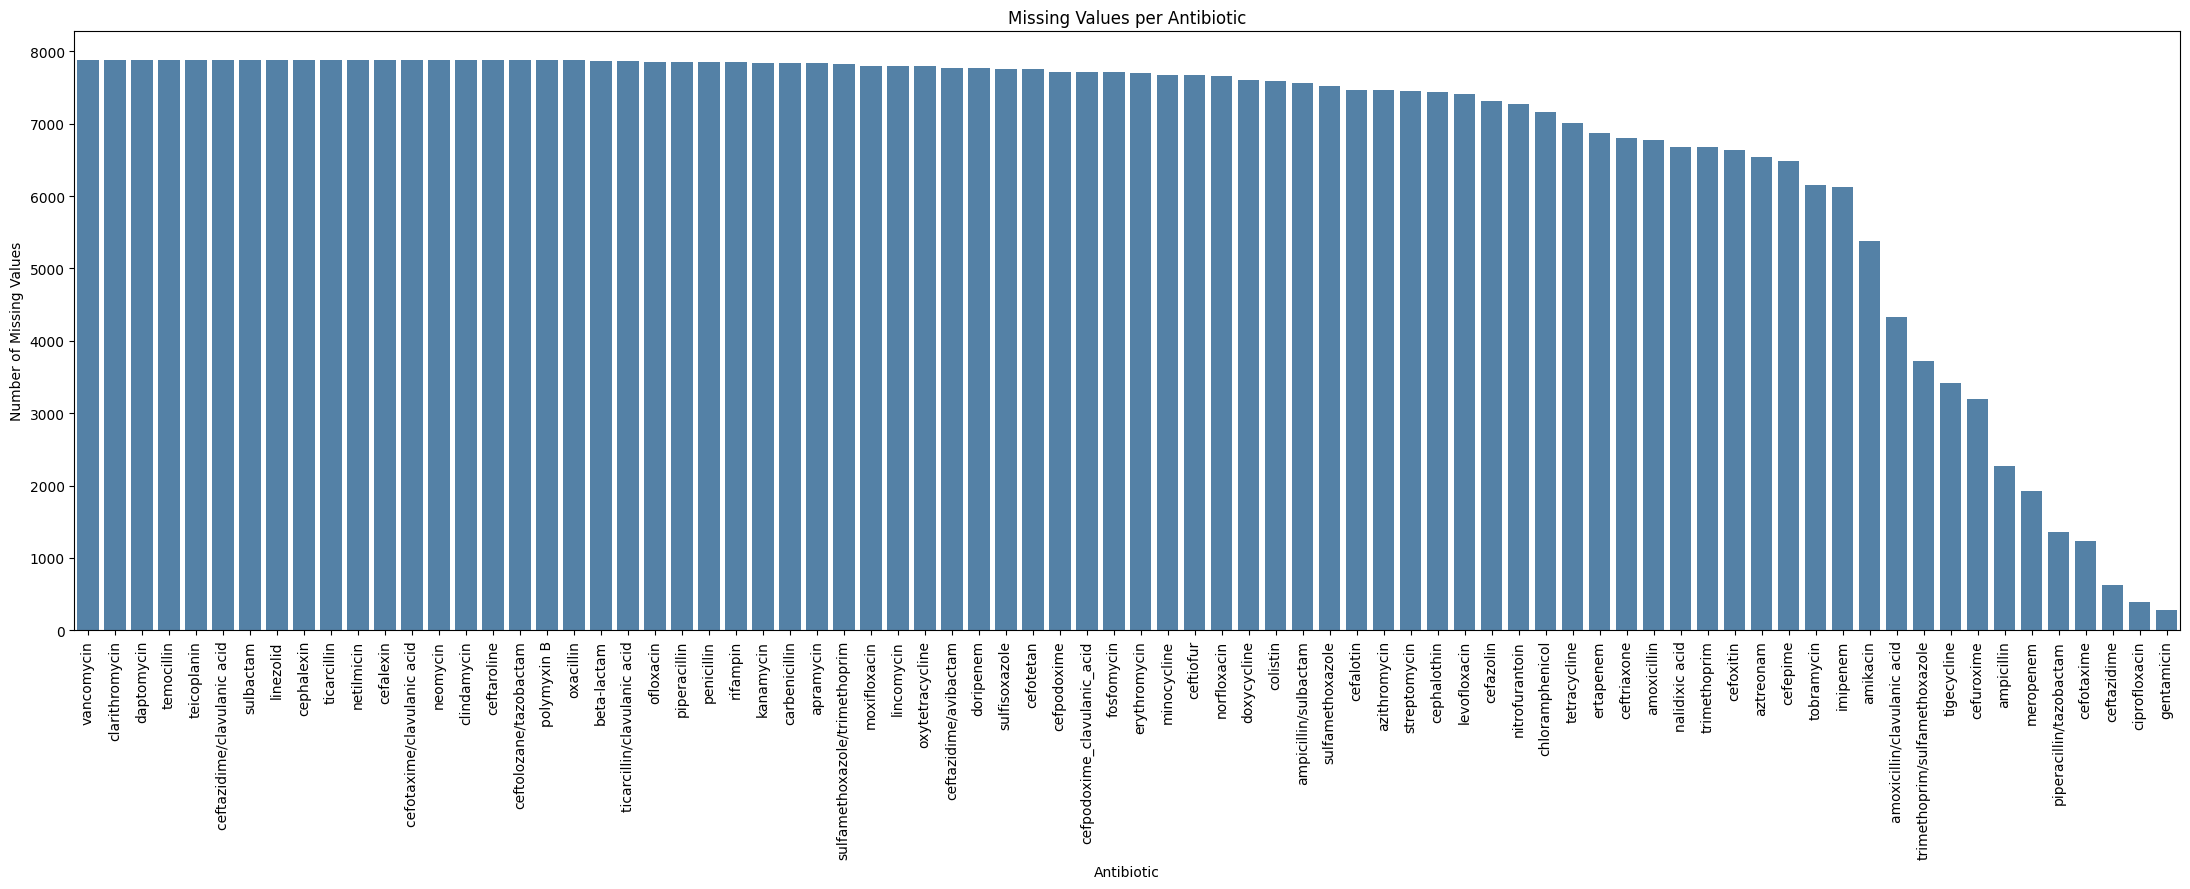

In [ ]:
# count plot of missing values per antibiotics
missing_df = missing_values.sort_values(ascending=False).reset_index()
missing_df.columns = ['Antibiotic', 'Missing_Count']

plt.figure(figsize=(22, 9))
sns.barplot(data=missing_df, x='Antibiotic', y='Missing_Count', color='steelblue')
plt.xticks(rotation=90)
plt.title('Missing Values per Antibiotic')
plt.xlabel('Antibiotic')
plt.ylabel('Number of Missing Values')
plt.tight_layout()
plt.show()




In [13]:
# drop antibiotics with more than 50% missing values
threshold = len(amr_matrix) * 0.5
amr_matrix = amr_matrix.loc[:, ~(amr_matrix.isnull().sum() > threshold)]
amr_matrix


Antibiotic,ampicillin,cefotaxime,ceftazidime,cefuroxime,ciprofloxacin,gentamicin,meropenem,piperacillin/tazobactam,tigecycline,trimethoprim/sulfamethoxazole
Genome Name,,,,,,,,,,
Escherichia coli 001-E1-DxU,2.0,NaN,2.0,NaN,2.0,2.0,0.0,NaN,NaN,2.0
Escherichia coli 001-E1-S04,2.0,NaN,2.0,NaN,2.0,2.0,0.0,NaN,NaN,2.0
Escherichia coli 001-E1-S06,2.0,NaN,2.0,NaN,2.0,2.0,0.0,NaN,NaN,2.0
Escherichia coli 00116690-7bb9-11e9-a8d3-68b59976a384,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,2.0
Escherichia coli 002-E1-DxU,2.0,NaN,2.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...
Escherichia coli strain WU40,2.0,NaN,2.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0
Escherichia coli strain WU43,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0
Escherichia coli strain WU44,2.0,NaN,2.0,NaN,2.0,0.0,0.0,NaN,NaN,0.0


In [14]:
# Get genome ID of the 7884 genomes in amr_matrix as a list
genome_id_map = combined_df.drop_duplicates(subset=['Genome Name']).set_index('Genome Name')['Genome ID']
target_genome_ids = amr_matrix.index.map(genome_id_map).tolist()

print(f"Number of Genome IDs retrieved: {len(target_genome_ids)}")
target_genome_ids

# save list to file
with open("../data/genome_ids.txt", "w") as f:
    for genome_id in target_genome_ids:
        f.write(f"{genome_id}\n")
        


Number of Genome IDs retrieved: 7884


In [15]:
# add genome ID to amr_matrix
amr_matrix.insert(0, 'Genome ID', target_genome_ids )

# reset index to have genome name as a column
amr_matrix.reset_index(inplace=True)
amr_matrix

Antibiotic,Genome Name,Genome ID,ampicillin,cefotaxime,ceftazidime,cefuroxime,ciprofloxacin,gentamicin,meropenem,piperacillin/tazobactam,tigecycline,trimethoprim/sulfamethoxazole
0,Escherichia coli 001-E1-DxU,562.140902,2.0,NaN,2.0,NaN,2.0,2.0,0.0,NaN,NaN,2.0
1,Escherichia coli 001-E1-S04,562.140907,2.0,NaN,2.0,NaN,2.0,2.0,0.0,NaN,NaN,2.0
2,Escherichia coli 001-E1-S06,562.140901,2.0,NaN,2.0,NaN,2.0,2.0,0.0,NaN,NaN,2.0
3,Escherichia coli 00116690-7bb9-11e9-a8d3-68b59...,562.100421,0.0,0.0,0.0,2.0,0.0,1.0,0.0,0.0,0.0,2.0
4,Escherichia coli 002-E1-DxU,562.140904,2.0,NaN,2.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
7879,Escherichia coli strain WU40,562.586470,2.0,NaN,2.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0
7880,Escherichia coli strain WU43,562.586460,0.0,NaN,0.0,NaN,0.0,0.0,0.0,NaN,NaN,0.0
7881,Escherichia coli strain WU44,562.586450,2.0,NaN,2.0,NaN,2.0,0.0,0.0,NaN,NaN,0.0
7882,Escherichia coli strain WU45,562.586510,2.0,NaN,1.0,NaN,2.0,0.0,0.0,NaN,NaN,0.0


In [17]:
amr_matrix.isnull().sum().sort_values()

Antibiotic
Genome Name                         0
Genome ID                           0
gentamicin                        279
ciprofloxacin                     390
ceftazidime                       625
cefotaxime                       1233
piperacillin/tazobactam          1359
meropenem                        1925
ampicillin                       2270
cefuroxime                       3195
tigecycline                      3424
trimethoprim/sulfamethoxazole    3717
dtype: int64

In [23]:
# see antibiotic distribution
amr_matrix.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7884 entries, 0 to 7883
Data columns (total 12 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Genome Name                    7884 non-null   object 
 1   Genome ID                      7884 non-null   float64
 2   ampicillin                     5614 non-null   float64
 3   cefotaxime                     6651 non-null   float64
 4   ceftazidime                    7259 non-null   float64
 5   cefuroxime                     4689 non-null   float64
 6   ciprofloxacin                  7494 non-null   float64
 7   gentamicin                     7605 non-null   float64
 8   meropenem                      5959 non-null   float64
 9   piperacillin/tazobactam        6525 non-null   float64
 10  tigecycline                    4460 non-null   float64
 11  trimethoprim/sulfamethoxazole  4167 non-null   float64
dtypes: float64(11), object(1)
memory usage: 739.3+ K

In [24]:
# checking class distribution for each antibiotics
amr_matrix.ampicillin.value_counts()

ampicillin
2.0    3188
0.0    2414
1.0      12
Name: count, dtype: int64

In [36]:
amr_matrix[amr_matrix['Genome ID']==562.2287]

Antibiotic,Genome Name,Genome ID,ampicillin,cefotaxime,ceftazidime,cefuroxime,ciprofloxacin,gentamicin,meropenem,piperacillin/tazobactam,tigecycline,trimethoprim/sulfamethoxazole
3556,Escherichia coli O83:H31 strain ECO0488,562.2287,NaN,NaN,0.0,2.0,0.0,0.0,NaN,0.0,NaN,NaN


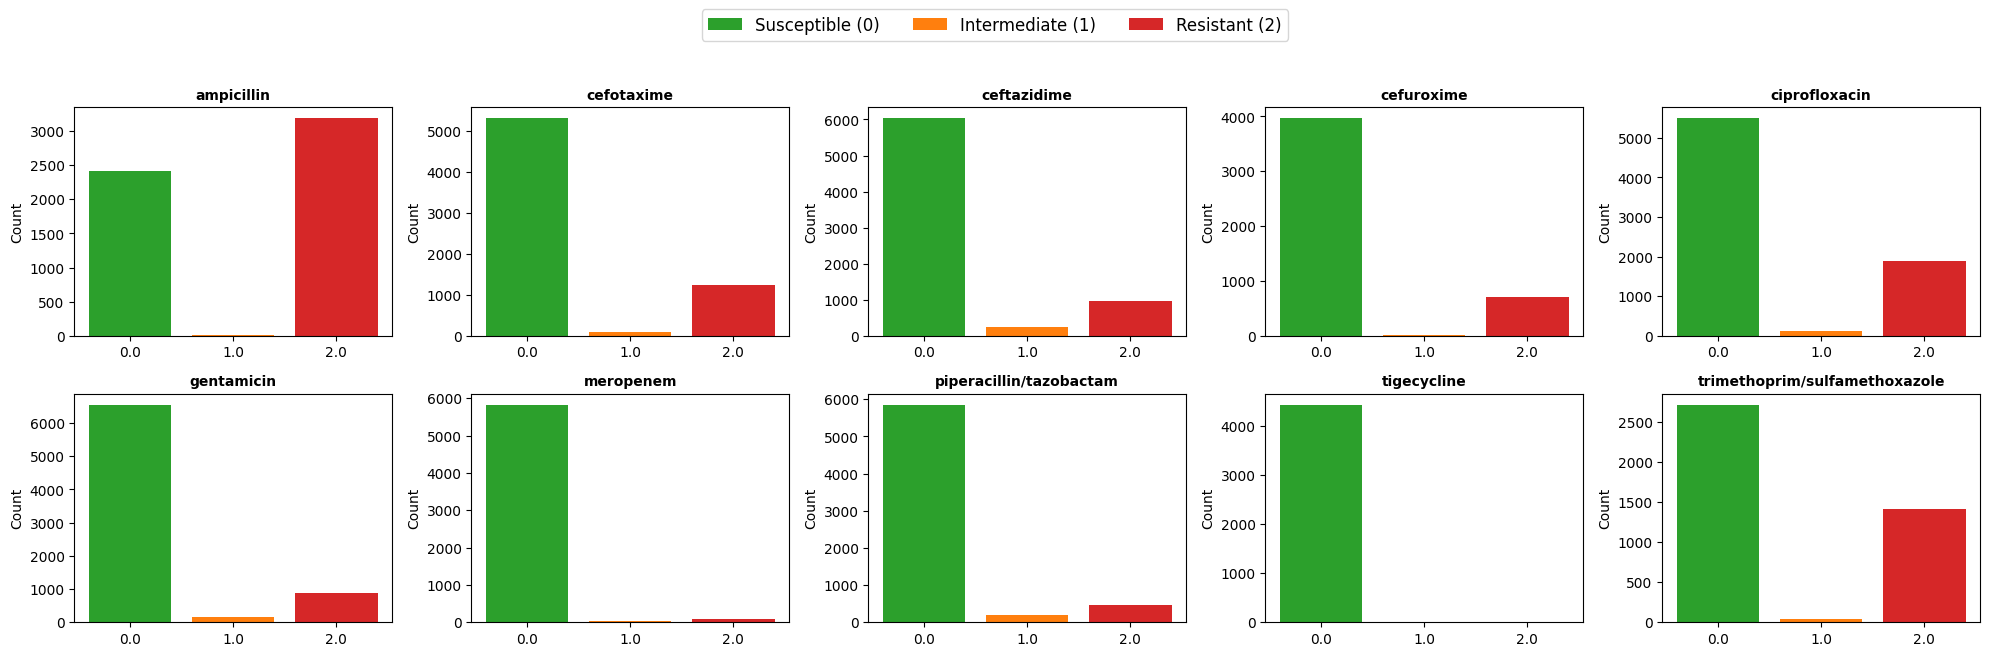

In [ ]:
# plot distribution of classes for all antibiotics
import math

antibiotics = amr_matrix.drop(columns=['Genome Name', 'Genome ID'])
num_antibiotics = len(antibiotics.columns)

# Determine grid size (e.g., 5 columns, and as many rows as needed)
cols = 5
rows = math.ceil(num_antibiotics / cols)

# Create a large figure with subplots
fig, axes = plt.subplots(rows, cols, figsize=(20, 3 * rows))
axes = axes.flatten() # Flatten the 2D array of axes for easy iteration

# Define colors for the classes: Susceptible (0), Intermediate (1), Resistant (2)
colors = {0.0: '#2ca02c', 1.0: '#ff7f0e', 2.0: '#d62728'} 

for i, col in enumerate(antibiotics.columns):
    # Get value counts and sort the index so 0, 1, 2 are in order
    counts = antibiotics[col].value_counts().sort_index()
    
    # Map the index to the corresponding colors
    bar_colors = [colors.get(x, 'gray') for x in counts.index]
    
    axes[i].bar(counts.index.astype(str), counts.values, color=bar_colors)
    axes[i].set_title(col, fontsize=10, fontweight='bold')
    axes[i].set_ylabel('Count')

# Hide any extra empty subplots if the grid is larger than the number of antibiotics
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

# Create a custom legend for the whole figure
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#2ca02c', label='Susceptible (0)'),
    Patch(facecolor='#ff7f0e', label='Intermediate (1)'),
    Patch(facecolor='#d62728', label='Resistant (2)')
]
fig.legend(handles=legend_elements, loc='lower center', bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.98]) 
plt.show()

In [13]:
# read data
kmer = pd.read_csv('../kmer-data.csv')
kmer.head()

,Unnamed: 0,AAAAAAAAAC,AAAAAAAACC,AAAAAAAACG,AAAAAAAAGA,AAAAAAAAGC,AAAAAAAATG,AAAAAAAATT,AAAAAAACAA,AAAAAAACAC,...,TTTGCGCAAA,TTTGCTAAAA,TTTGGAAAAA,TTTGGTAAAA,TTTGTACAAA,TTTGTGAAAA,TTTTAAAAAA,TTTTACAAAA,TTTTAGAAAA,TTTTCGAAAA
0,562.2285,2.0,4.0,1.0,1.0,4.0,4.0,4.0,1.0,2.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,562.2282,2.0,7.0,4.0,3.0,9.0,4.0,1.0,4.0,4.0,...,2.0,4.0,1.0,6.0,2.0,6.0,3.0,4.0,2.0,3.0


In [15]:
kmer.describe()

,Unnamed: 0,AAAAAAAAAC,AAAAAAAACC,AAAAAAAACG,AAAAAAAAGA,AAAAAAAAGC,AAAAAAAATG,AAAAAAAATT,AAAAAAACAA,AAAAAAACAC,...,TTTGCGCAAA,TTTGCTAAAA,TTTGGAAAAA,TTTGGTAAAA,TTTGTACAAA,TTTGTGAAAA,TTTTAAAAAA,TTTTACAAAA,TTTTAGAAAA,TTTTCGAAAA
count,2.000000,2.0,2.00000,2.00000,2.000000,2.000000,2.0,2.00000,2.00000,2.000000,...,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.00000,2.000000,2.000000,2.00000
mean,562.228350,2.0,5.50000,2.50000,2.000000,6.500000,4.0,2.50000,2.50000,3.000000,...,1.000000,2.000000,0.500000,3.000000,1.000000,3.000000,1.50000,2.000000,1.000000,1.50000
std,0.000212,0.0,2.12132,2.12132,1.414214,3.535534,0.0,2.12132,2.12132,1.414214,...,1.414214,2.828427,0.707107,4.242641,1.414214,4.242641,2.12132,2.828427,1.414214,2.12132
min,562.228200,2.0,4.00000,1.00000,1.000000,4.000000,4.0,1.00000,1.00000,2.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.00000
25%,562.228275,2.0,4.75000,1.75000,1.500000,5.250000,4.0,1.75000,1.75000,2.500000,...,0.500000,1.000000,0.250000,1.500000,0.500000,1.500000,0.75000,1.000000,0.500000,0.75000
50%,562.228350,2.0,5.50000,2.50000,2.000000,6.500000,4.0,2.50000,2.50000,3.000000,...,1.000000,2.000000,0.500000,3.000000,1.000000,3.000000,1.50000,2.000000,1.000000,1.50000
75%,562.228425,2.0,6.25000,3.25000,2.500000,7.750000,4.0,3.25000,3.25000,3.500000,...,1.500000,3.000000,0.750000,4.500000,1.500000,4.500000,2.25000,3.000000,1.500000,2.25000
max,562.228500,2.0,7.00000,4.00000,3.000000,9.000000,4.0,4.00000,4.00000,4.000000,...,2.000000,4.000000,1.000000,6.000000,2.000000,6.000000,3.00000,4.000000,2.000000,3.00000


In [ ]:
kmers_long = pd.read_csv("../kmer-data-long.csv")  # GenomeID, kmer, count

kmer_matrix = kmers_long.pivot_table(
    index="GenomeID",
    columns="kmer",
    values="count",
    aggfunc="sum",
    fill_value=0,
).reset_index()  # <- makes GenomeID a column

kmer_matrix.head()
# Optionally make it sparse for memory
# kmer_matrix.iloc[:, 1:] = kmer_matrix.iloc[:, 1:].astype("Sparse[int]")